<a href="https://colab.research.google.com/github/arthur-craveiro1/calculo-numerico/blob/master/CN_Atividade1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [154]:
import numpy as np
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Parte A - Truncamento e Arredondamento

In [155]:
x_1 = 3.14159265
x_2 = 98.76543
x_3 = 0.00498765

casas_decimais = [0,1,2,3,4]
numeros = [x_1,x_2,x_3]

def truncamento(x, n):
    return math.trunc((10.0**n) * x) / (10.0**n)

def erro_absoluto(x,x_til):
  return abs(x-x_til)

def erro_relativo(x,x_til):
  return erro_absoluto(x,x_til) / x

def erro_percentual(x,x_til):
  return erro_relativo(x,x_til) * 100


dados = []

for i in numeros:
  for j in casas_decimais:
      truncado = truncamento(i, j)
      arredondado = round(i, j)

      erro_abs_trunc = erro_absoluto(i, truncado)
      erro_rel_trunc = erro_relativo(i, truncado)
      erro_perc_trunc = erro_percentual(i, truncado)

      erro_abs_arred = erro_absoluto(i, arredondado)
      erro_rel_arred = erro_relativo(i, arredondado)
      erro_perc_arred = erro_percentual(i, arredondado)

      dados.append([i, truncado, arredondado, erro_abs_trunc, erro_rel_trunc, erro_perc_trunc,
                    erro_abs_arred, erro_rel_arred, erro_perc_arred])

df_parte_A = pd.DataFrame(dados, columns=['Número', 'Truncamento', 'Arredondamento',
                                  'Erro Absoluto Truncamento', 'Erro Relativo Truncamento', 'Erro Percentual Truncamento',
                                  'Erro Absoluto Arredondamento', 'Erro Relativo Arredondamento', 'Erro Percentual Arredondamento'])

display(df_parte_A.head(15))




,Número,Truncamento,Arredondamento,Erro Absoluto Truncamento,Erro Relativo Truncamento,Erro Percentual Truncamento,Erro Absoluto Arredondamento,Erro Relativo Arredondamento,Erro Percentual Arredondamento
0,3.141593,3.0000,3.0000,0.141593,4.507034e-02,4.507034,0.141593,4.507034e-02,4.507034
1,3.141593,3.1000,3.1000,0.041593,1.323935e-02,1.323935,0.041593,1.323935e-02,1.323935
2,3.141593,3.1400,3.1400,0.001593,5.069562e-04,0.050696,0.001593,5.069562e-04,0.050696
3,3.141593,3.1410,3.1420,0.000593,1.886464e-04,0.018865,0.000407,1.296635e-04,0.012966
4,3.141593,3.1415,3.1416,0.000093,2.949141e-05,0.002949,0.000007,2.339578e-06,0.000234
5,98.765430,98.0000,99.0000,0.765430,7.749979e-03,0.774998,0.234570,2.375021e-03,0.237502
6,98.765430,98.7000,98.8000,0.065430,6.624788e-04,0.066248,0.034570,3.500213e-04,0.035002
7,98.765430,98.7600,98.7700,0.005430,5.497875e-05,0.005498,0.004570,4.627125e-05,0.004627
8,98.765430,98.7650,98.7650,0.000430,4.353750e-06,0.000435,0.000430,4.353750e-06,0.000435
9,98.765430,98.7654,98.7654,0.000030,3.037500e-07,0.000030,0.000030,3.037500e-07,0.000030


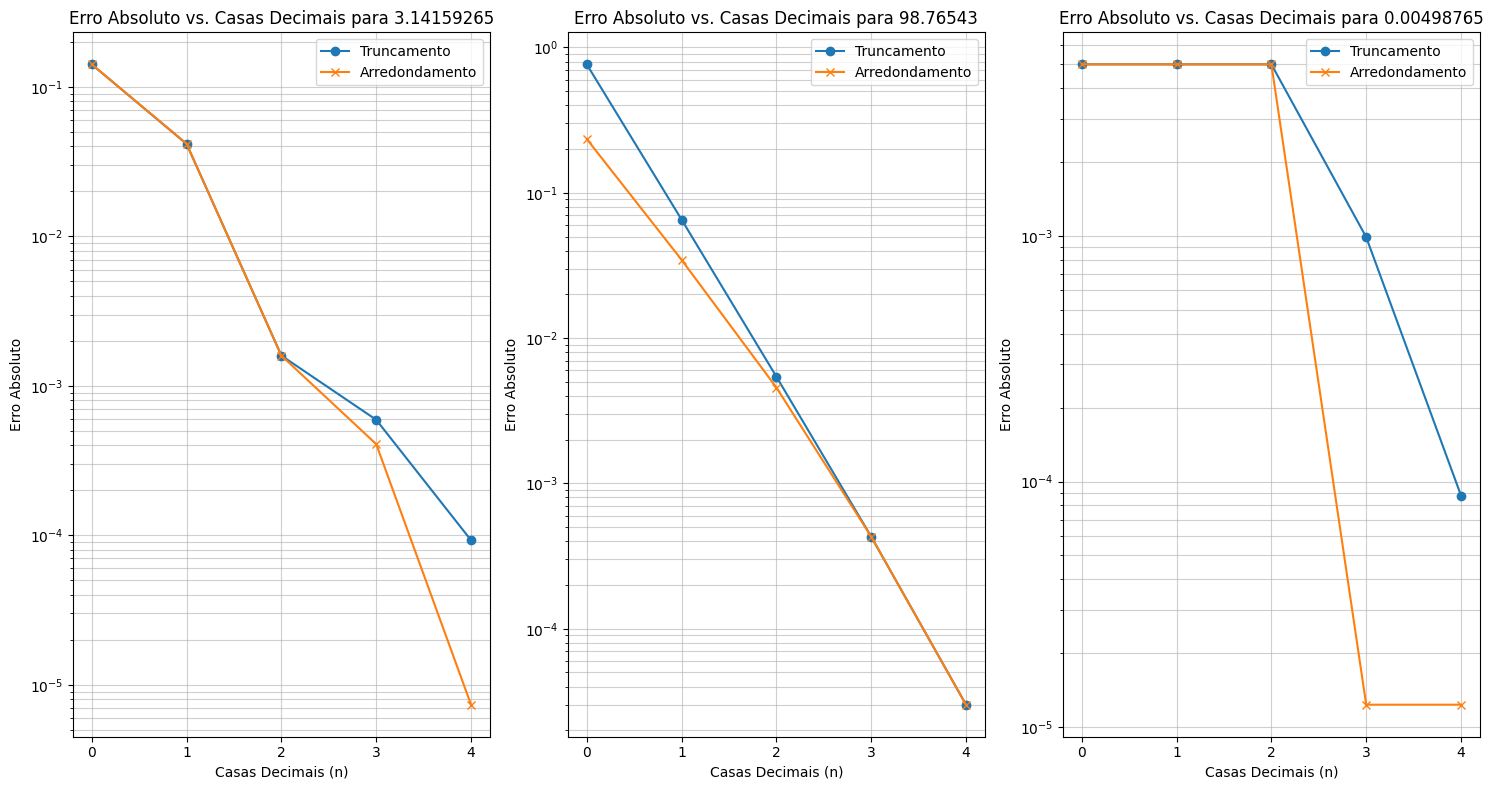

In [156]:
plt.figure(figsize=(15, 8))

for i, numero_original in enumerate(numeros):
    df_filtered = df_parte_A[df_parte_A['Número'] == numero_original]

    plt.subplot(1, len(numeros), i + 1) # Create subplots for each original number

    # Plotting for Truncamento
    plt.plot(casas_decimais, df_filtered['Erro Absoluto Truncamento'], marker='o', label='Truncamento')
    # Plotting for Arredondamento
    plt.plot(casas_decimais, df_filtered['Erro Absoluto Arredondamento'], marker='x', label='Arredondamento')

    plt.title(f'Erro Absoluto vs. Casas Decimais para {numero_original}')
    plt.xlabel('Casas Decimais (n)')
    plt.ylabel('Erro Absoluto')
    plt.xticks(casas_decimais)
    plt.yscale('log') # Use log scale for better visualization of small errors
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.6)

plt.tight_layout()
plt.show()

## Questão 5
Arredondar sempre gera erro menor ou igual ao truncamento?

R: Ao arredondar um número, você está escolhendo o número representável mais próximo, o que minimiza a diferença entre o número original e o valor aproximado. No truncamento, você simplesmente descarta os dígitos após um certo ponto, o que sempre move o número em direção a zero e pode resultar em um erro maior se o dígito descartado for 5 ou superior.

Observando os resultados da tabela df e os gráficos gerados, você pode verificar que a coluna 'Erro Absoluto Arredondamento' geralmente apresenta valores menores ou iguais à coluna 'Erro Absoluto Truncamento'. Isso ocorre porque o arredondamento leva em consideração o próximo dígito para fazer uma escolha mais precisa, enquanto o truncamento apenas "corta" o número, independentemente do valor do próximo dígito. Nos casos em que o dígito a ser descartado é menor que 5, o arredondamento pode coincidir com o truncamento (erro igual). Quando o dígito é 5 ou maior, o arredondamento ajusta o último dígito, frequentemente resultando em um erro menor do que se o número fosse simplesmente truncado.

# Parte B

In [157]:
dados_originais = [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]

referencia = np.mean(dados_originais)

dados_arredondados = []
dados_truncados = []

for i in dados_originais:
  dados_arredondados.append(round(i))
  dados_truncados.append(math.trunc(i))

medias = [referencia, np.mean(dados_arredondados), np.mean(dados_truncados)]
desvios = [np.std(dados_originais), np.std(dados_arredondados), np.std(dados_truncados)]
mins = [np.min(dados_originais), np.min(dados_arredondados), np.min(dados_truncados)]
maxs = [np.max(dados_originais), np.max(dados_arredondados), np.max(dados_truncados)]
amplitude = [max - min for max, min in zip(maxs, mins)]

dados = {
    'Média': medias,
    'Desvio Padrão': desvios,
    'Mínimo': mins,
    'Máximo': maxs,
    'Amplitude': amplitude
}



df = pd.DataFrame(dados, index=['Original', 'Arredondado', 'Truncado'])
df['Erro Absoluto'] = df.apply(lambda row: abs(referencia - row['Média']), axis=1)
df['Erro Relativo'] = df.apply(lambda row: (abs(referencia - row['Média'])/row['Média']), axis=1)
df['Erro Percentual (%)'] = df.apply(lambda row: 100*row['Erro Relativo'], axis=1)


display(df)





,Média,Desvio Padrão,Mínimo,Máximo,Amplitude,Erro Absoluto,Erro Relativo,Erro Percentual (%)
Original,121.12,0.790949,119.8,122.4,2.6,0.00,0.000000,0.000000
Arredondado,121.10,0.830662,120.0,122.0,2.0,0.02,0.000165,0.016515
Truncado,120.70,0.900000,119.0,122.0,3.0,0.42,0.003480,0.347970


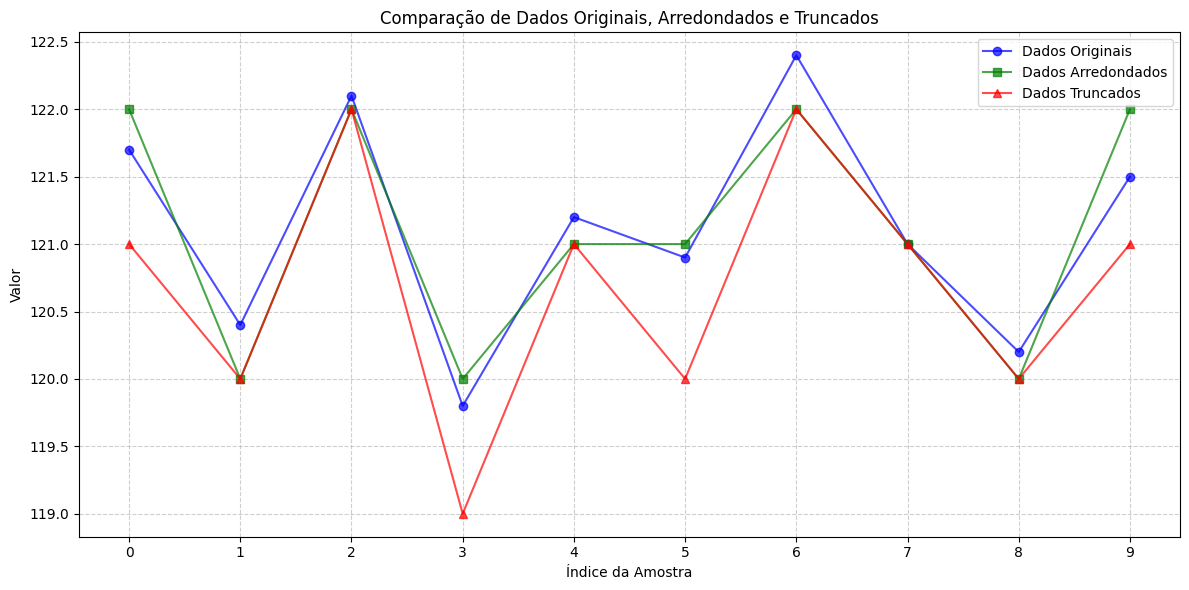

In [158]:
plt.figure(figsize=(12, 6))

# Scatter plot for original data
# plt.scatter(range(len(dados_originais)), dados_originais, color='blue', marker='o', label='Dados Originais', alpha=0.7)
plt.plot(range(len(dados_originais)), dados_originais, color='blue', marker='o', label='Dados Originais', alpha=0.7)

# Scatter plot for rounded data
# plt.scatter(range(len(dados_arredondados)), dados_arredondados, color='green', marker='s', label='Dados Arredondados', alpha=0.7)
plt.plot(range(len(dados_arredondados)), dados_arredondados, color='green', marker='s', label='Dados Arredondados', alpha=0.7)

# Scatter plot for truncated data
# plt.scatter(range(len(dados_truncados)), dados_truncados, color='red', marker='^', label='Dados Truncados', alpha=0.7)
plt.plot(range(len(dados_truncados)), dados_truncados, color='red', marker='^', label='Dados Truncados', alpha=0.7)


plt.title('Comparação de Dados Originais, Arredondados e Truncados')
plt.xlabel('Índice da Amostra')
plt.ylabel('Valor')
plt.xticks(range(len(dados_originais))) # Show all indices on x-axis
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6209/197491029.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_data.index, y=error_data.values, palette='viridis')


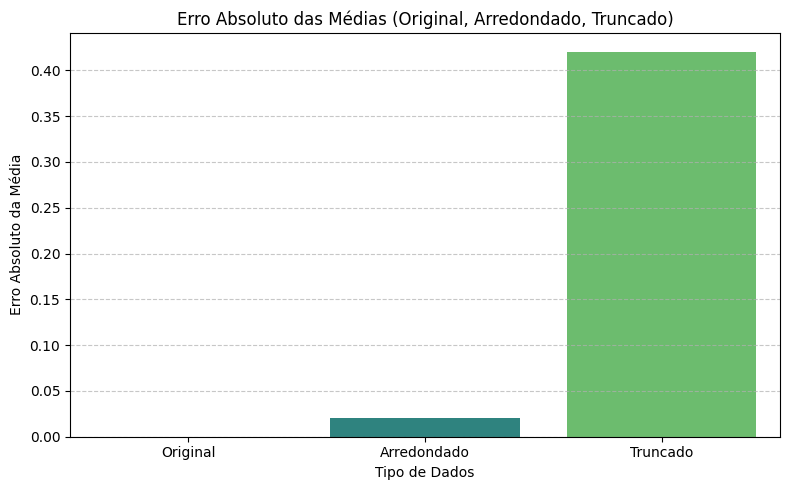

In [159]:
plt.figure(figsize=(8, 5))

# Get the 'Erro Absoluto' for 'Original', 'Arredondado', 'Truncado'
error_data = df.loc[['Original', 'Arredondado', 'Truncado'], 'Erro Absoluto']

sns.barplot(x=error_data.index, y=error_data.values, palette='viridis')

plt.title('Erro Absoluto das Médias (Original, Arredondado, Truncado)')
plt.xlabel('Tipo de Dados')
plt.ylabel('Erro Absoluto da Média')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6209/2610202788.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percent_error_data.index, y=percent_error_data.values, palette='plasma')


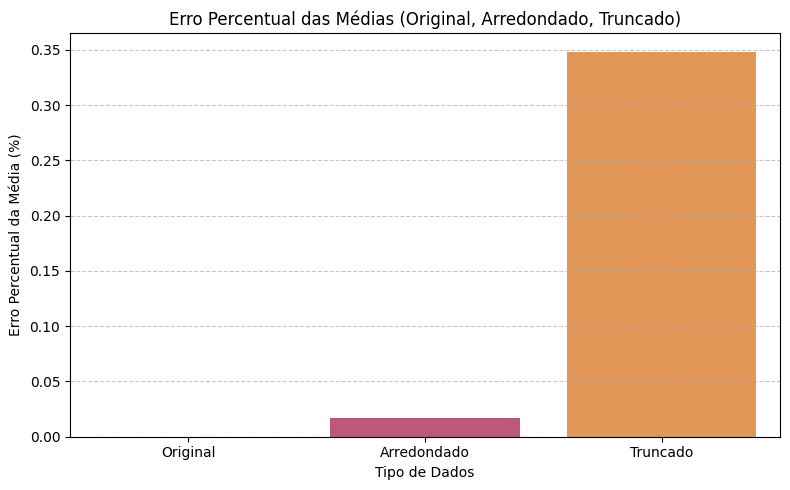

In [160]:
plt.figure(figsize=(8, 5))

# Get the 'Erro Percentual (%)' for 'Original', 'Arredondado', 'Truncado'
percent_error_data = df.loc[['Original', 'Arredondado', 'Truncado'], 'Erro Percentual (%)']

sns.barplot(x=percent_error_data.index, y=percent_error_data.values, palette='plasma')

plt.title('Erro Percentual das Médias (Original, Arredondado, Truncado)')
plt.xlabel('Tipo de Dados')
plt.ylabel('Erro Percentual da Média (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

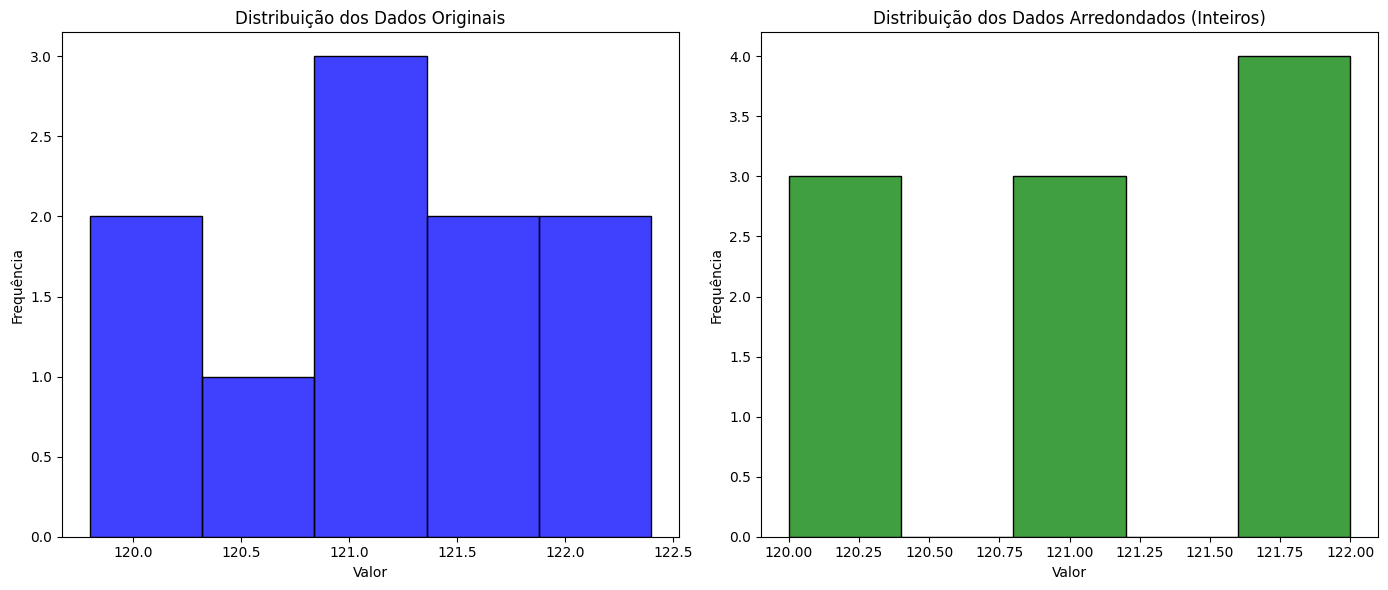

In [161]:
plt.figure(figsize=(14, 6))

# Histograma para Dados Originais
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(dados_originais, kde=False, color='blue', bins=5)
plt.title('Distribuição dos Dados Originais')
plt.xlabel('Valor')
plt.ylabel('Frequência')

# Histograma para Dados Arredondados
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(dados_arredondados, kde=False, color='green', bins=5)
plt.title('Distribuição dos Dados Arredondados (Inteiros)')
plt.xlabel('Valor')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

A média da amostra original é de 121.12, enquanto que a média dos dados arredondados é 121.10 e truncados é 120.70. Podemos ver que  o erro percentual de ambos os arredondamentos é bem pequeno(0.0165% e 0.3480%). Portanto, podemos considerar que a representação inteira preserva sim a média dos dados. No entando, a representação inteira afeta bem mais a variabilidade em comparação aos dados originais. Podemos perceber isto observando os histogramas: os dados arredondados, por terem menos espaço para variação, diminuem a variabilidade geral dos dados, mostrado pelas barras bem próximas uma das outras.

# Parte C1

In [162]:
r = 0.00080
L = 0.20
u = 0.0035
dp = 1200
pi = math.pi

# Calculando usando os valores fornecidos
Q1 = (pi * math.pow(r,4) * dp) / (8*u*L)

#r arredondado e truncado para uma casa decimal em mm;
Q2_1 = (pi * math.pow(round(r, 4),4) * dp) / (8*u*L)
Q2_2 = (pi * math.pow(truncamento(r, 4),4) * dp) / (8*u*L)


#μ arredondada e truncada para três casas decimais em Pa s;
Q3_1 = (pi * math.pow(r,4) * dp) / (8*round(u,3)*L)
Q3_2 = (pi * math.pow(r,4) * dp) / (8*truncamento(u, 3)*L)

#∆p arredondada e truncada para centenas de pascal;
Q4_1 = (pi * math.pow(r,4) * round(dp,-2)) / (8*u*L)
Q4_2 = (pi * math.pow(r,4) * truncamento(dp,-2)) / (8*u*L)

# Todas as aproximações simultaneamente

# Arredondamentos
Q5_1 = (pi * math.pow(round(r,4),4) * round(dp,-2)) / (8*round(u,3)*L)
# Truncamentos
Q5_2 = (pi * math.pow(truncamento(r,4),4) * truncamento(dp,-2)) / (8*truncamento(u,3)*L)

# Erros
print("Q1 =", Q1)

print("\nQ2 arredondado:")
print("Erro absoluto =", erro_absoluto(Q1, Q2_1))
print("Erro relativo =", erro_relativo(Q1, Q2_1))
print("Erro percentual =", erro_percentual(Q1, Q2_1), "%")

print("\nQ2 truncado:")
print("Erro absoluto =", erro_absoluto(Q1, Q2_2))
print("Erro relativo =", erro_relativo(Q1, Q2_2))
print("Erro percentual =", erro_percentual(Q1, Q2_2), "%")

print("\nQ3 arredondado:")
print("Erro absoluto =", erro_absoluto(Q1, Q3_1))
print("Erro relativo =", erro_relativo(Q1, Q3_1))
print("Erro percentual =", erro_percentual(Q1, Q3_1), "%")

print("\nQ3 truncado:")
print("Erro absoluto =", erro_absoluto(Q1, Q3_2))
print("Erro relativo =", erro_relativo(Q1, Q3_2))
print("Erro percentual =", erro_percentual(Q1, Q3_2), "%")

print("\nQ4 arredondado:")
print("Erro absoluto =", erro_absoluto(Q1, Q4_1))
print("Erro relativo =", erro_relativo(Q1, Q4_1))
print("Erro percentual =", erro_percentual(Q1, Q4_1), "%")

print("\nQ4 truncado:")
print("Erro absoluto =", erro_absoluto(Q1, Q4_2))
print("Erro relativo =", erro_relativo(Q1, Q4_2))
print("Erro percentual =", erro_percentual(Q1, Q4_2), "%")

print("\nQ5 arredondado:")
print("Erro absoluto =", erro_absoluto(Q1, Q5_1))
print("Erro relativo =", erro_relativo(Q1, Q5_1))
print("Erro percentual =", erro_percentual(Q1, Q5_1), "%")

print("\nQ5 truncado:")
print("Erro absoluto =", erro_absoluto(Q1, Q5_2))
print("Erro relativo =", erro_relativo(Q1, Q5_2))
print("Erro percentual =", erro_percentual(Q1, Q5_2), "%")

Q1 = 2.757420751950813e-07

Q2 arredondado:
Erro absoluto = 0.0
Erro relativo = 0.0
Erro percentual = 0.0 %

Q2 truncado:
Erro absoluto = 0.0
Erro relativo = 0.0
Erro percentual = 0.0 %

Q3 arredondado:
Erro absoluto = 3.446775939938513e-08
Erro relativo = 0.12499999999999988
Erro percentual = 12.499999999999988 %

Q3 truncado:
Erro absoluto = 4.5957012532513556e-08
Erro relativo = 0.16666666666666669
Erro percentual = 16.666666666666668 %

Q4 arredondado:
Erro absoluto = 0.0
Erro relativo = 0.0
Erro percentual = 0.0 %

Q4 truncado:
Erro absoluto = 0.0
Erro relativo = 0.0
Erro percentual = 0.0 %

Q5 arredondado:
Erro absoluto = 3.446775939938513e-08
Erro relativo = 0.12499999999999988
Erro percentual = 12.499999999999988 %

Q5 truncado:
Erro absoluto = 4.5957012532513556e-08
Erro relativo = 0.16666666666666669
Erro percentual = 16.666666666666668 %


# Parte C2

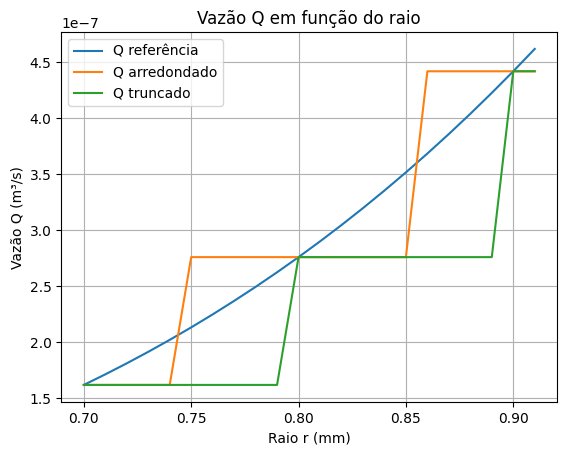

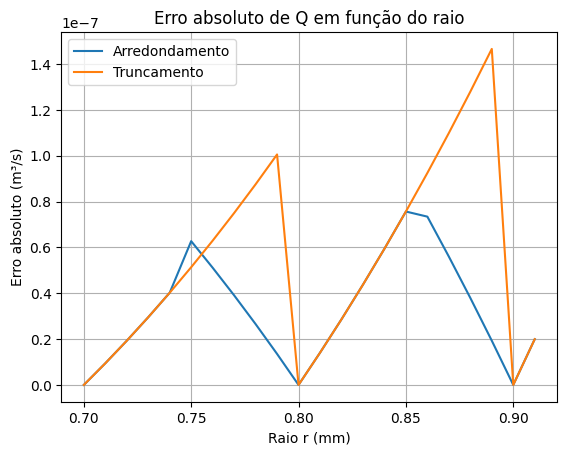

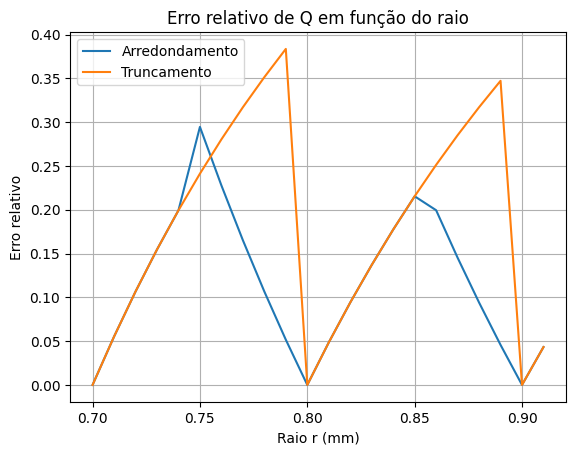

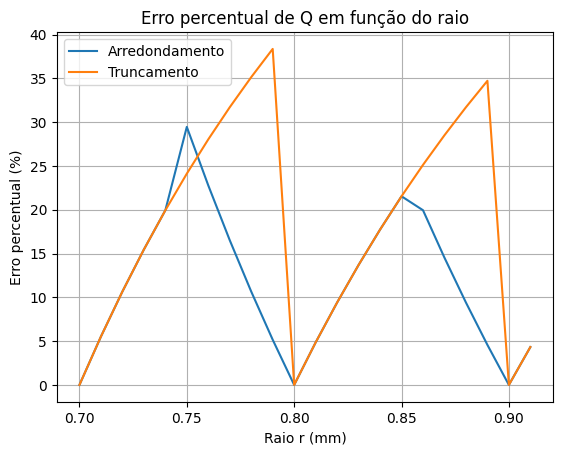

In [163]:
# Constantes
L = 0.20
u = 0.0035
dp = 1200
pi = math.pi


# Raios de 0,70 mm até 0,90 mm
# passo de 0,01 mm
raios_mm = np.arange(0.70, 0.91, 0.01)


# Listas para armazenar os resultados
Q_referencia = []
Q_arredondado = []
Q_truncado = []

erro_abs_arred = []
erro_abs_trunc = []

erro_rel_arred = []
erro_rel_trunc = []

erro_perc_arred = []
erro_perc_trunc = []


# Cálculos para cada raio
for r_mm in raios_mm:

    # Raio original convertido para metros
    r = r_mm * 1e-3

    # Q de referência usando o raio original
    Q = (pi * r**4 * dp) / (8*u*L)

    # Raio arredondado para uma casa decimal em mm
    r_arred = round(r_mm, 1) * 1e-3

    # Raio truncado para uma casa decimal em mm
    r_trunc = truncamento(r_mm, 1) * 1e-3

    # Q usando raio arredondado
    Q_arred = (pi * r_arred**4 * dp) / (8*u*L)

    # Q usando raio truncado
    Q_trunc = (pi * r_trunc**4 * dp) / (8*u*L)


    # Armazenando Q
    Q_referencia.append(Q)
    Q_arredondado.append(Q_arred)
    Q_truncado.append(Q_trunc)


    # Erros absolutos
    erro_abs_arred.append(erro_absoluto(Q, Q_arred))
    erro_abs_trunc.append(erro_absoluto(Q, Q_trunc))

    # Erros relativos
    erro_rel_arred.append(erro_relativo(Q, Q_arred))
    erro_rel_trunc.append(erro_relativo(Q, Q_trunc))

    # Erros percentuais
    erro_perc_arred.append(erro_percentual(Q, Q_arred))
    erro_perc_trunc.append(erro_percentual(Q, Q_trunc))


# ============================================================
# 1. Q em função de r
# ============================================================

plt.figure()

plt.plot(raios_mm, Q_referencia, label="Q referência")
plt.plot(raios_mm, Q_arredondado, label="Q arredondado")
plt.plot(raios_mm, Q_truncado, label="Q truncado")

plt.xlabel("Raio r (mm)")
plt.ylabel("Vazão Q (m³/s)")
plt.title("Vazão Q em função do raio")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 2. Erro absoluto de Q em função de r
# ============================================================

plt.figure()

plt.plot(raios_mm, erro_abs_arred, label="Arredondamento")
plt.plot(raios_mm, erro_abs_trunc, label="Truncamento")

plt.xlabel("Raio r (mm)")
plt.ylabel("Erro absoluto (m³/s)")
plt.title("Erro absoluto de Q em função do raio")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 3. Erro relativo de Q em função de r
# ============================================================

plt.figure()

plt.plot(raios_mm, erro_rel_arred, label="Arredondamento")
plt.plot(raios_mm, erro_rel_trunc, label="Truncamento")

plt.xlabel("Raio r (mm)")
plt.ylabel("Erro relativo")
plt.title("Erro relativo de Q em função do raio")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# 4. Erro percentual de Q em função de r
# ============================================================

plt.figure()

plt.plot(raios_mm, erro_perc_arred, label="Arredondamento")
plt.plot(raios_mm, erro_perc_trunc, label="Truncamento")

plt.xlabel("Raio r (mm)")
plt.ylabel("Erro percentual (%)")
plt.title("Erro percentual de Q em função do raio")
plt.legend()
plt.grid()

plt.show()

Explique por que o erro no raio é amplificado na vazão. Relacione sua resposta ao expoente
quatro.

R: O erro no raio amplifica na vazão justamente por conta do raio estar elevado ao expoente 4. Por estar no grau 4, o raio transporta seu erro junto com seu expoente, elevando o erro também ao quarto grau.

# Parte D

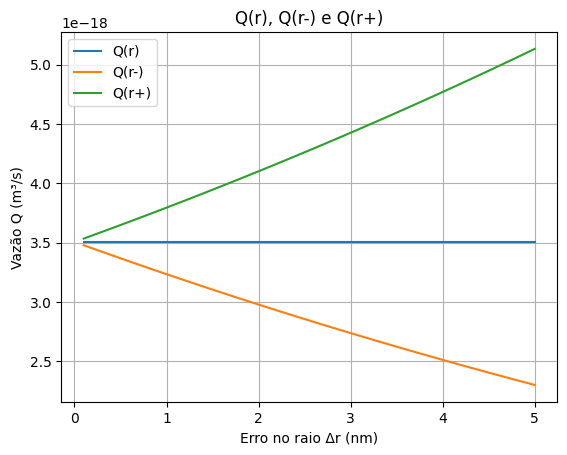

In [164]:
# Declaração de variáveis
r = 50       # nm
L = 10       # um
u = 0.00035  # Pa.s
dp = 5000    # Pa

delta_r = np.arange(0.1, 5.1, 0.1)

r_menos = r - delta_r
r_mais = r + delta_r


# Função de cálculo
def Hagen_Poiseuille(r, L, u, dp):
    r = r * 1e-9
    L = L * 1e-6

    return (math.pi * math.pow(r, 4) * dp) / (8*u*L)


# Vazão de referência
Q_ref = Hagen_Poiseuille(r, L, u, dp)


# Listas
vazoes_r = [Q_ref] * len(delta_r)
vazoes_r_menos = []
vazoes_r_mais = []


# Cálculo de Q(r-) e Q(r+)
for i in range(len(delta_r)):

    vazoes_r_menos.append(
        Hagen_Poiseuille(r_menos[i], L, u, dp)
    )

    vazoes_r_mais.append(
        Hagen_Poiseuille(r_mais[i], L, u, dp)
    )


# Gráfico
plt.figure()

plt.plot(delta_r, vazoes_r, label="Q(r)")
plt.plot(delta_r, vazoes_r_menos, label="Q(r-)")
plt.plot(delta_r, vazoes_r_mais, label="Q(r+)")

plt.xlabel("Erro no raio Δr (nm)")
plt.ylabel("Vazão Q (m³/s)")
plt.title("Q(r), Q(r-) e Q(r+)")

plt.legend()
plt.grid()

plt.show()

# Parte D2

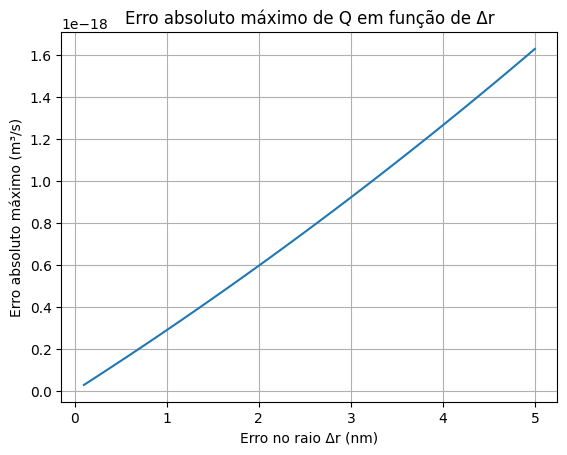

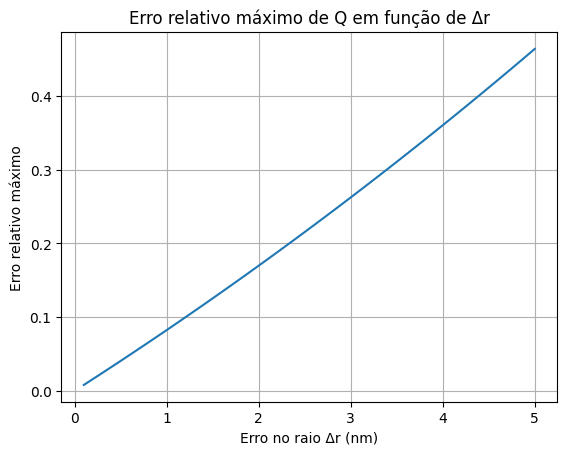

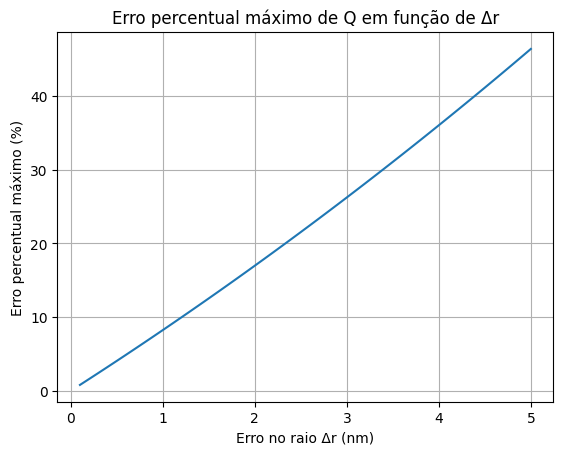

In [165]:
# Listas para armazenar os erros
erros_absolutos_max = []
erros_relativos_max = []
erros_percentuais_max = []


# Calculando os erros para cada Δr
for i in range(len(delta_r)):

    # Erros absolutos
    erro_menos = abs(vazoes_r_menos[i] - Q_ref)
    erro_mais = abs(vazoes_r_mais[i] - Q_ref)

    # Erro absoluto máximo
    erro_abs_max = max(erro_menos, erro_mais)

    # Erro relativo máximo
    erro_rel_max = erro_abs_max / Q_ref

    # Erro percentual máximo
    erro_perc_max = erro_rel_max * 100


    # Armazenando os resultados
    erros_absolutos_max.append(erro_abs_max)
    erros_relativos_max.append(erro_rel_max)
    erros_percentuais_max.append(erro_perc_max)


# ============================================================
# 2. Gráfico do erro absoluto máximo
# ============================================================

plt.figure()

plt.plot(delta_r, erros_absolutos_max)

plt.xlabel("Erro no raio Δr (nm)")
plt.ylabel("Erro absoluto máximo (m³/s)")
plt.title("Erro absoluto máximo de Q em função de Δr")

plt.grid()
plt.show()


# ============================================================
# 3. Gráfico do erro relativo máximo
# ============================================================

plt.figure()

plt.plot(delta_r, erros_relativos_max)

plt.xlabel("Erro no raio Δr (nm)")
plt.ylabel("Erro relativo máximo")
plt.title("Erro relativo máximo de Q em função de Δr")

plt.grid()
plt.show()


# ============================================================
# 4. Gráfico do erro percentual máximo
# ============================================================

plt.figure()

plt.plot(delta_r, erros_percentuais_max)

plt.xlabel("Erro no raio Δr (nm)")
plt.ylabel("Erro percentual máximo (%)")
plt.title("Erro percentual máximo de Q em função de Δr")

plt.grid()
plt.show()

A aproximação linear permite estimar diretamente o erro na vazão a partir de uma pequena variação no raio. Como \(Q\propto r^4\), temos:

$$ \Delta Q \approx \left|\frac{dQ}{dr}\right|\Delta r = \frac{4Q}{r}\Delta r $$

Os resultados mostram que, para pequenos valores de \(\Delta r\), a aproximação linear fornece uma boa estimativa do erro. À medida que \(\Delta r\) aumenta, a diferença em relação ao erro calculado diretamente também aumenta, devido à não linearidade da relação Q∝r

# Seção D2

In [166]:
import math
import numpy as np


# ============================================================
# Declaração das variáveis
# ============================================================

r32 = np.float32(50e-9)       # 50 nm -> m
L32 = np.float32(10e-6)       # 10 um -> m
u32 = np.float32(3.5e-3)      # Pa.s
dp32 = np.float32(5000)       # Pa

r64 = np.float64(50e-9)
L64 = np.float64(10e-6)
u64 = np.float64(3.5e-3)
dp64 = np.float64(5000)


# ============================================================
# r^4 em cada precisão
# ============================================================

r4_32 = r32**4
r4_64 = r64**4

print("r^4 float32 =", r4_32)
print("r^4 float64 =", r4_64)


# ============================================================
# Q em cada precisão
# ============================================================

Q32 = (np.float32(np.pi) * r4_32 * dp32) / (8*u32*L32)

Q64 = (np.float64(np.pi) * r4_64 * dp64) / (8*u64*L64)

print("\nQ float32 =", Q32)
print("Q float64 =", Q64)


# ============================================================
# Diferença absoluta e relativa entre os resultados
# ============================================================

diferenca_absoluta = abs(Q64 - Q32)

diferenca_relativa = diferenca_absoluta / abs(Q64)

print("\nDiferença absoluta =", diferenca_absoluta)
print("Diferença relativa =", diferenca_relativa)
print("Diferença percentual =", diferenca_relativa * 100, "%")


# ============================================================
# Epsilon de cada precisão
# ============================================================

print("\neps float32 =", np.finfo(np.float32).eps)
print("eps float64 =", np.finfo(np.float64).eps)


# ============================================================
# Pequenas variações de Δr/r
# ============================================================

razoes = [
    1e-1,
    1e-2,
    1e-3,
    1e-4,
    1e-5,
    1e-6,
    1e-7,
    1e-8
]


# ============================================================
# Expressões δ1 e δ2
# ============================================================

for x in razoes:

    # Δr/r = x
    delta_r32 = r32 * np.float32(x)
    delta_r64 = r64 * np.float64(x)


    # --------------------------------------------------------
    # float32
    # --------------------------------------------------------

    Q_r32 = (
        np.float32(np.pi) *
        r32**4 *
        dp32
    ) / (np.float32(8)*u32*L32)

    Q_r_mais32 = (
        np.float32(np.pi) *
        (r32 + delta_r32)**4 *
        dp32
    ) / (np.float32(8)*u32*L32)


    delta1_32 = (Q_r_mais32 - Q_r32) / Q_r32

    delta2_32 = (
        (np.float32(1) + delta_r32/r32)**4
        - np.float32(1)
    )


    # --------------------------------------------------------
    # float64
    # --------------------------------------------------------

    Q_r64 = (
        np.float64(np.pi) *
        r64**4 *
        dp64
    ) / (np.float64(8)*u64*L64)

    Q_r_mais64 = (
        np.float64(np.pi) *
        (r64 + delta_r64)**4 *
        dp64
    ) / (np.float64(8)*u64*L64)


    delta1_64 = (Q_r_mais64 - Q_r64) / Q_r64

    delta2_64 = (
        (np.float64(1) + delta_r64/r64)**4
        - np.float64(1)
    )


    # --------------------------------------------------------
    # Resultados
    # --------------------------------------------------------

    print("\nΔr/r =", x)

    print("float32:")
    print("  δ1 =", delta1_32)
    print("  δ2 =", delta2_32)

    print("float64:")
    print("  δ1 =", delta1_64)
    print("  δ2 =", delta2_64)

r^4 float32 = 6.2500004e-30
r^4 float64 = 6.249999999999999e-30

Q float32 = 3.5062423e-19
Q float64 = 3.506241800881465e-19

Diferença absoluta = 5.228627689184328e-26
Diferença relativa = 1.4912342006389455e-07
Diferença percentual = 1.4912342006389455e-05 %

eps float32 = 1.1920929e-07
eps float64 = 2.220446049250313e-16

Δr/r = 0.1
float32:
  δ1 = 0.46410006
  δ2 = 0.46410012
float64:
  δ1 = 0.46409999999999957
  δ2 = 0.4641000000000004

Δr/r = 0.01
float32:
  δ1 = 0.040603746
  δ2 = 0.040603995
float64:
  δ1 = 0.04060400999999966
  δ2 = 0.040604010000000024

Δr/r = 0.001
float32:
  δ1 = 0.0040060105
  δ2 = 0.0040061474
float64:
  δ1 = 0.0040060040009997095
  δ2 = 0.004006004000999486

Δr/r = 0.0001
float32:
  δ1 = 0.00039987857
  δ2 = 0.00040018559
float64:
  δ1 = 0.00040006000399993394
  δ2 = 0.0004000600039999469

Δr/r = 1e-05
float32:
  δ1 = 4.0105813e-05
  δ2 = 4.005432e-05
float64:
  δ1 = 4.000060000380733e-05
  δ2 = 4.0000600004308495e-05

Δr/r = 1e-06
float32:
  δ1 = 3.9073

# Seção D3

A redução da escala aumenta a razão superfície/volume, pois a área superficial varia aproximadamente com o quadrado do tamanho, enquanto o volume varia com o cubo. Assim, à medida que as dimensões diminuem, uma parcela maior do fluido fica próxima às paredes do tubo, tornando os efeitos viscosos e o atrito com a parede mais importantes. No caso de um nanocateter, esses efeitos podem dominar o escoamento e fazer com que pequenas variações no raio provoquem grandes alterações na vazão, como indicado pela relação $$\(Q\propto r^4\).$$

In [167]:
# ============================================================
# EXPORTAR TODOS OS GRÁFICOS EM UM ÚNICO PNG
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from io import BytesIO

# ------------------------------------------------------------
# Recria o DataFrame original da PARTE A
# ------------------------------------------------------------

dados_A = []

for numero in numeros:
    for n in casas_decimais:

        truncado = truncamento(numero, n)
        arredondado = round(numero, n)

        dados_A.append([
            numero,
            truncado,
            arredondado,
            erro_absoluto(numero, truncado),
            erro_relativo(numero, truncado),
            erro_percentual(numero, truncado),
            erro_absoluto(numero, arredondado),
            erro_relativo(numero, arredondado),
            erro_percentual(numero, arredondado)
        ])

df_A = pd.DataFrame(
    dados_A,
    columns=[
        'Número',
        'Truncamento',
        'Arredondamento',
        'Erro Absoluto Truncamento',
        'Erro Relativo Truncamento',
        'Erro Percentual Truncamento',
        'Erro Absoluto Arredondamento',
        'Erro Relativo Arredondamento',
        'Erro Percentual Arredondamento'
    ]
)

# ------------------------------------------------------------
# Lista onde serão armazenadas as imagens
# ------------------------------------------------------------

imagens = []


def salvar_figura_na_memoria(fig):
    """
    Converte uma figura Matplotlib em imagem PIL
    sem precisar salvar arquivos intermediários.
    """
    buffer = BytesIO()

    fig.savefig(
        buffer,
        format='png',
        dpi=180,
        bbox_inches='tight'
    )

    buffer.seek(0)

    return Image.open(buffer).convert('RGB')


# ============================================================
# PARTE A
# ============================================================

fig, axes = plt.subplots(
    1,
    len(numeros),
    figsize=(18, 5)
)

for i, numero in enumerate(numeros):

    ax = axes[i]

    dados_numero = df_A[
        df_A['Número'] == numero
    ]

    ax.plot(
        casas_decimais,
        dados_numero['Erro Absoluto Truncamento'],
        marker='o',
        label='Truncamento'
    )

    ax.plot(
        casas_decimais,
        dados_numero['Erro Absoluto Arredondamento'],
        marker='x',
        label='Arredondamento'
    )

    ax.set_title(
        f'Erro Absoluto vs. Casas Decimais\n{numero}'
    )

    ax.set_xlabel('Casas Decimais (n)')
    ax.set_ylabel('Erro Absoluto')

    ax.set_xticks(casas_decimais)

    ax.set_yscale('log')

    ax.grid(
        True,
        which='both',
        alpha=0.5
    )

    ax.legend()

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# ============================================================
# PARTE B
# ============================================================

# B1 - Comparação dos dados

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    range(len(dados_originais)),
    dados_originais,
    marker='o',
    label='Original'
)

ax.plot(
    range(len(dados_arredondados)),
    dados_arredondados,
    marker='s',
    label='Arredondado'
)

ax.plot(
    range(len(dados_truncados)),
    dados_truncados,
    marker='^',
    label='Truncado'
)

ax.set_title('Comparação dos Dados')
ax.set_xlabel('Índice')
ax.set_ylabel('Valor')
ax.legend()
ax.grid(True, alpha=0.5)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# B2 - Erro absoluto das médias

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    error_data.index.astype(str),
    error_data.values
)

ax.set_title('Erro Absoluto das Médias')
ax.set_ylabel('Erro Absoluto')

ax.grid(
    axis='y',
    alpha=0.5
)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# B3 - Erro percentual das médias

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    percent_error_data.index.astype(str),
    percent_error_data.values
)

ax.set_title('Erro Percentual das Médias')
ax.set_ylabel('Erro Percentual (%)')

ax.grid(
    axis='y',
    alpha=0.5
)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# B4 - Histogramas

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].hist(
    dados_originais,
    bins=5
)

axes[0].set_title(
    'Distribuição dos Dados Originais'
)

axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frequência')


axes[1].hist(
    dados_arredondados,
    bins=5
)

axes[1].set_title(
    'Distribuição dos Dados Arredondados'
)

axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frequência')

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# ============================================================
# PARTE C
# ============================================================

# C1 - Q x raio

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    raios_mm,
    Q_referencia,
    label='Referência'
)

ax.plot(
    raios_mm,
    Q_arredondado,
    label='Arredondado'
)

ax.plot(
    raios_mm,
    Q_truncado,
    label='Truncado'
)

ax.set_title('Q em Função do Raio')
ax.set_xlabel('Raio r (mm)')
ax.set_ylabel('Q')

ax.legend()
ax.grid(True, alpha=0.5)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# C2 - Erro absoluto

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    raios_mm,
    erro_abs_arred,
    label='Arredondamento'
)

ax.plot(
    raios_mm,
    erro_abs_trunc,
    label='Truncamento'
)

ax.set_title(
    'Erro Absoluto de Q'
)

ax.set_xlabel('Raio r (mm)')
ax.set_ylabel('Erro Absoluto')

ax.legend()
ax.grid(True, alpha=0.5)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# C3 - Erro relativo

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    raios_mm,
    erro_rel_arred,
    label='Arredondamento'
)

ax.plot(
    raios_mm,
    erro_rel_trunc,
    label='Truncamento'
)

ax.set_title(
    'Erro Relativo de Q'
)

ax.set_xlabel('Raio r (mm)')
ax.set_ylabel('Erro Relativo')

ax.legend()
ax.grid(True, alpha=0.5)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# C4 - Erro percentual

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    raios_mm,
    erro_perc_arred,
    label='Arredondamento'
)

ax.plot(
    raios_mm,
    erro_perc_trunc,
    label='Truncamento'
)

ax.set_title(
    'Erro Percentual de Q'
)

ax.set_xlabel('Raio r (mm)')
ax.set_ylabel('Erro Percentual (%)')

ax.legend()
ax.grid(True, alpha=0.5)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# ============================================================
# PARTE D
# ============================================================

# D1 - Q(r), Q(r-) e Q(r+)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    delta_r,
    vazoes_r,
    label='Q(r)'
)

ax.plot(
    delta_r,
    vazoes_r_menos,
    label='Q(r-)'
)

ax.plot(
    delta_r,
    vazoes_r_mais,
    label='Q(r+)'
)

ax.set_title(
    'Q(r), Q(r-) e Q(r+)'
)

ax.set_xlabel('Δr')
ax.set_ylabel('Q')

ax.legend()
ax.grid(True, alpha=0.5)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# D2 - Erro absoluto máximo

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    delta_r,
    erros_absolutos_max
)

ax.set_title(
    'Erro Absoluto Máximo'
)

ax.set_xlabel('Δr')
ax.set_ylabel('Erro Absoluto Máximo')

ax.grid(True, alpha=0.5)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# D3 - Erro relativo máximo

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    delta_r,
    erros_relativos_max
)

ax.set_title(
    'Erro Relativo Máximo'
)

ax.set_xlabel('Δr')
ax.set_ylabel('Erro Relativo Máximo')

ax.grid(True, alpha=0.5)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# D4 - Erro percentual máximo

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    delta_r,
    erros_percentuais_max
)

ax.set_title(
    'Erro Percentual Máximo'
)

ax.set_xlabel('Δr')
ax.set_ylabel('Erro Percentual Máximo (%)')

ax.grid(True, alpha=0.5)

plt.tight_layout()

imagens.append(
    salvar_figura_na_memoria(fig)
)

plt.close(fig)


# ============================================================
# MONTAR UMA ÚNICA IMAGEM
# ============================================================

colunas = 2
linhas = int(np.ceil(len(imagens) / colunas))

largura = max(img.width for img in imagens)
altura = max(img.height for img in imagens)

margem = 30

imagem_final = Image.new(
    'RGB',
    (
        colunas * largura + (colunas + 1) * margem,
        linhas * altura + (linhas + 1) * margem
    ),
    'white'
)

for i, img in enumerate(imagens):

    coluna = i % colunas
    linha = i // colunas

    x = margem + coluna * largura
    y = margem + linha * altura

    imagem_final.paste(
        img,
        (x, y)
    )


# ============================================================
# SALVAR PNG FINAL
# ============================================================

imagem_final.save(
    'todos_os_graficos.png',
    format='PNG'
)

print('==============================================')
print('ARQUIVO GERADO COM SUCESSO!')
print('==============================================')
print(f'Total de figuras: {len(imagens)}')
print('Arquivo: todos_os_graficos.png')

ARQUIVO GERADO COM SUCESSO!
Total de figuras: 13
Arquivo: todos_os_graficos.png


# Parte 8

GIF salvo como: atividade_8_nanocanal.gif


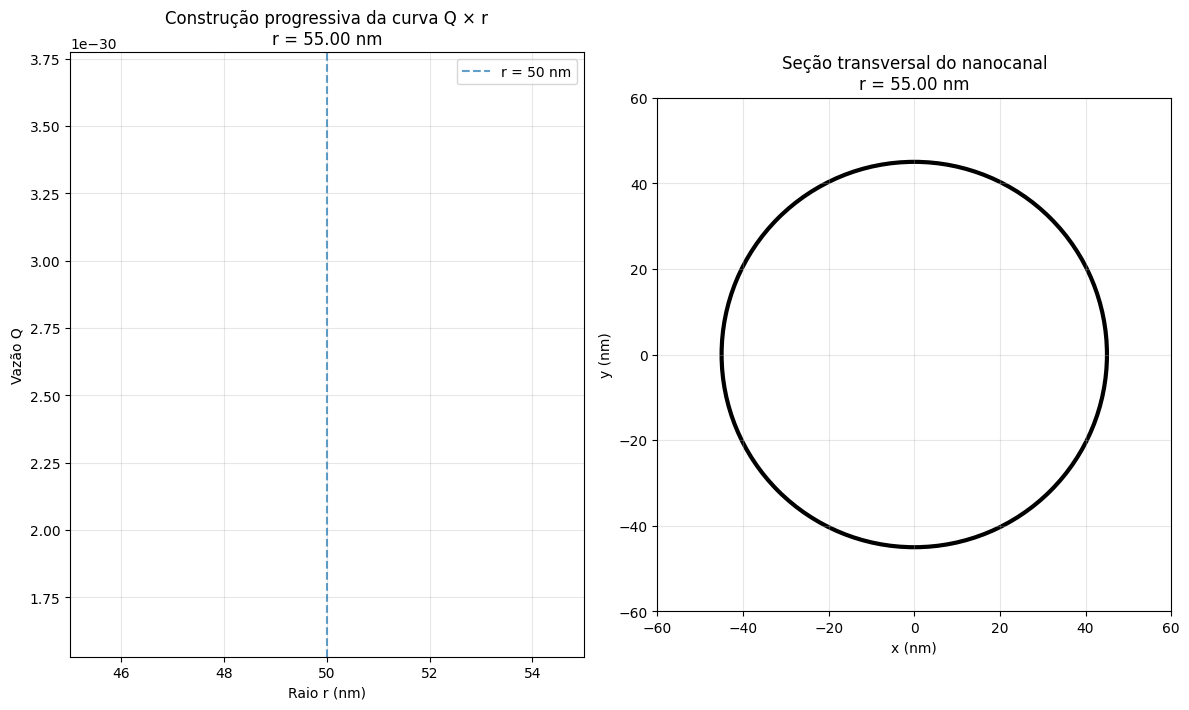

In [169]:
# ============================================================
# ATIVIDADE 8 - GIF DEMONSTRATIVO
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ============================================================
# PARÂMETROS
# ============================================================

# Intervalo do raio do nanocanal
r_min = 45       # nm
r_max = 55       # nm

# Número de quadros do GIF
n_quadros = 50

# Raio de referência
r_ref_nm = 50

# ------------------------------------------------------------
# IMPORTANTE:
# Use aqui os mesmos parâmetros da Atividade anterior.
# ------------------------------------------------------------

# Exemplo da equação de Hagen-Poiseuille:
#
# Q = (pi * r^4 * DeltaP) / (8 * mu * L)
#
# Coloque abaixo os mesmos valores utilizados anteriormente.

DeltaP = 1.0       # diferença de pressão
mu = 1.0           # viscosidade
L = 1.0            # comprimento do canal

# ============================================================
# FUNÇÃO DA VAZÃO
# ============================================================

def calcular_Q(r_nm):

    # conversão de nm para metros
    r_m = r_nm * 1e-9

    Q = (
        np.pi * r_m**4 * DeltaP
        / (8 * mu * L)
    )

    return Q


# ============================================================
# RAIOS E VAZÕES
# ============================================================

raios = np.linspace(
    r_min,
    r_max,
    n_quadros
)

Q_valores = np.array([
    calcular_Q(r)
    for r in raios
])

# Vazão correspondente a r = 50 nm
Q_ref = calcular_Q(r_ref_nm)


# ============================================================
# ERRO PERCENTUAL
# ============================================================

erro_percentual = (
    np.abs(Q_valores - Q_ref)
    / np.abs(Q_ref)
    * 100
)


# ============================================================
# CONFIGURAÇÃO DA FIGURA
# ============================================================

fig = plt.figure(
    figsize=(12, 7)
)

# Gráfico principal
ax1 = fig.add_subplot(1, 2, 1)

# Seção transversal
ax2 = fig.add_subplot(1, 2, 2)

# ============================================================
# LIMITES DO GRÁFICO Q x r
# ============================================================

ax1.set_xlim(
    r_min,
    r_max
)

ax1.set_ylim(
    Q_valores.min() * 0.95,
    Q_valores.max() * 1.05
)

ax1.set_xlabel(
    'Raio r (nm)'
)

ax1.set_ylabel(
    'Vazão Q'
)

ax1.set_title(
    'Construção progressiva da curva Q × r'
)

ax1.grid(
    True,
    alpha=0.3
)


# ============================================================
# OBJETOS DA ANIMAÇÃO
# ============================================================

linha_Q, = ax1.plot(
    [],
    [],
    linewidth=2
)

ponto_atual, = ax1.plot(
    [],
    [],
    'o',
    markersize=8
)

linha_ref = ax1.axvline(
    r_ref_nm,
    linestyle='--',
    alpha=0.7,
    label='r = 50 nm'
)

ax1.legend()


# ============================================================
# SEÇÃO TRANSVERSAL DO NANOCANAL
# ============================================================

ax2.set_aspect(
    'equal'
)

ax2.set_xlim(
    -60,
    60
)

ax2.set_ylim(
    -60,
    60
)

ax2.set_xlabel(
    'x (nm)'
)

ax2.set_ylabel(
    'y (nm)'
)

ax2.set_title(
    'Seção transversal do nanocanal'
)

ax2.grid(
    True,
    alpha=0.3
)

# Círculo que representa o canal
circulo = plt.Circle(
    (0, 0),
    r_min,
    fill=False,
    linewidth=3
)

ax2.add_patch(
    circulo
)

# ============================================================
# TEXTO INFORMATIVO
# ============================================================

texto = ax2.text(
    0.5,
    -0.15,
    '',
    transform=ax2.transAxes,
    ha='center',
    va='top',
    fontsize=11
)


# ============================================================
# FUNÇÃO DE INICIALIZAÇÃO
# ============================================================

def init():

    linha_Q.set_data(
        [],
        []
    )

    ponto_atual.set_data(
        [],
        []
    )

    circulo.set_radius(
        r_min
    )

    texto.set_text(
        ''
    )

    return (
        linha_Q,
        ponto_atual,
        circulo,
        texto
    )


# ============================================================
# FUNÇÃO DE ATUALIZAÇÃO
# ============================================================

def atualizar(i):

    r_atual = raios[i]
    Q_atual = Q_valores[i]
    erro_atual = erro_percentual[i]

    # --------------------------------------------------------
    # Curva Q x r sendo construída progressivamente
    # --------------------------------------------------------

    linha_Q.set_data(
        raios[:i+1],
        Q_valores[:i+1]
    )

    ponto_atual.set_data(
        [r_atual],
        [Q_atual]
    )

    # --------------------------------------------------------
    # Atualiza o círculo da seção transversal
    # --------------------------------------------------------

    circulo.set_radius(
        r_atual
    )

    # --------------------------------------------------------
    # Atualiza as informações
    # --------------------------------------------------------

    texto.set_text(
        f'Raio atual: {r_atual:.2f} nm\n'
        f'Vazão: {Q_atual:.4e}\n'
        f'Erro em relação a r = 50 nm: '
        f'{erro_atual:.2f}%'
    )

    # --------------------------------------------------------
    # Título
    # --------------------------------------------------------

    ax1.set_title(
        f'Construção progressiva da curva Q × r\n'
        f'r = {r_atual:.2f} nm'
    )

    ax2.set_title(
        f'Seção transversal do nanocanal\n'
        f'r = {r_atual:.2f} nm'
    )

    return (
        linha_Q,
        ponto_atual,
        circulo,
        texto
    )


# ============================================================
# CRIAÇÃO DA ANIMAÇÃO
# ============================================================

animacao = FuncAnimation(
    fig,
    atualizar,
    frames=n_quadros,
    init_func=init,
    interval=100,
    blit=False,
    repeat=True
)

plt.tight_layout()


# ============================================================
# MOSTRAR NO GOOGLE COLAB
# ============================================================

HTML(
    animacao.to_jshtml()
)

# ============================================================
# EXPORTAR PARA GIF
# ============================================================

animacao.save(
    'atividade_8_nanocanal.gif',
    writer='pillow',
    fps=10
)

print('GIF salvo como: atividade_8_nanocanal.gif')